In [1]:
import sys
import os

# Add parent directory to path to import from src/
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

import torch
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

Project root: d:\Research\smap recharge\SMAP-Recharge-Flux
Using device: cpu


In [2]:
# Path to base checkpoint (from initial training on Jan-Mar data)
BASE_CHECKPOINT = 'checkpoints_train/checkpoint_final.pt'

# Network configurations (must match base training)
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

In [11]:
# === LOAD CALHOUN CCZO PRECIPITATION DATA ===
# Read Calhoun precipitation data - second column only
print("Reading Calhoun precipitation data...")
data = np.genfromtxt('../data/CalhounPrecipWY2015.csv', delimiter=',', skip_header=1, dtype=str)

# Extract second column (precipitation in mm at 5-min resolution)
precip_mm_5min = np.array([float(row[1]) for row in data])

print(f"Original data: {len(precip_mm_5min)} points at 5-min resolution")

# Group every 12 points (60 minutes = 12 * 5 minutes)
n_groups = len(precip_mm_5min) // 12
precip_mm_60min = []

for i in range(n_groups):
    # Sum precipitation over 12 points (60 minutes)
    total_mm_60min = precip_mm_5min[i*12:(i+1)*12].sum()
    precip_mm_60min.append(total_mm_60min)

precip_mm_60min = np.array(precip_mm_60min)

# Convert to m/s
# Total mm in 60 min -> m/s
# mm to m: divide by 1000
# 60 minutes = 3600 seconds
q = precip_mm_60min / 1000.0 / 3600.0  # m/s

# Extract a different time window for fine-tuning (days 165-180)
q_new = -q[24*130 : 24*145]
t_new = np.arange(len(q_new)) * 3600

print(f"\nResampled data: {len(t_new)} points at 60-min resolution")
print(f"Time span: {t_new[-1]/86400:.2f} days ({t_new[-1]/3600:.1f} hours)")
print(f"Precipitation rate range: {q_new.min():.2e} to {q_new.max():.2e} m/s")
print(f"Non-zero precipitation points: {(q_new > 0).sum()} ({(q_new > 0).sum()/len(q_new)*100:.1f}%)")

# Create new_q0_data tuple
new_q0_data = (t_new.tolist(), q_new.tolist())

print("\nnew_q0_data created successfully!")
print(f"  t: {len(t_new)} points from {t_new[0]/86400:.3f} to {t_new[-1]/86400:.3f} days")
print(f"  q: {len(q_new)} points in m/s")


Reading Calhoun precipitation data...
Original data: 92749 points at 5-min resolution

Resampled data: 360 points at 60-min resolution
Time span: 14.96 days (359.0 hours)
Precipitation rate range: -1.86e-06 to -0.00e+00 m/s
Non-zero precipitation points: 0 (0.0%)

new_q0_data created successfully!
  t: 360 points from 0.000 to 14.958 days
  q: 360 points in m/s


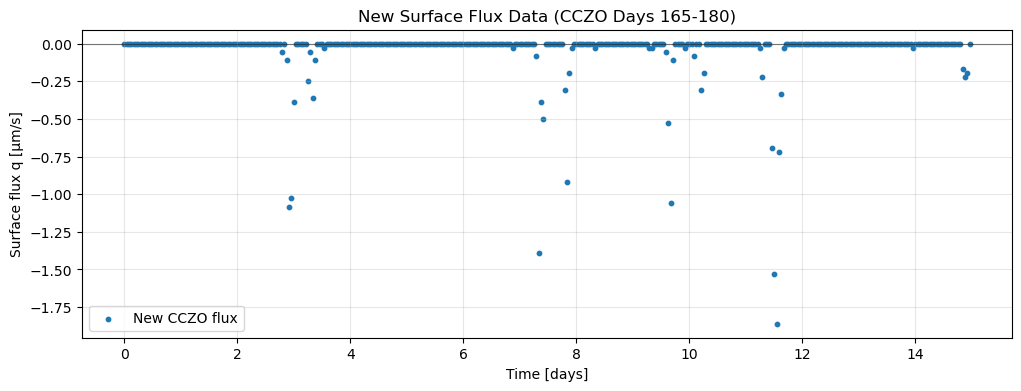


Data stats:
  Duration: 15.0 days
  Flux range: -1.86 to -0.00 μm/s
  Mean flux: -0.04 μm/s


In [12]:
# Plot the new surface flux
plt.figure(figsize=(12, 4))
plt.scatter(np.array(new_q0_data[0])/86400, np.array(new_q0_data[1])*1e6, s=10, label='New CCZO flux', color='tab:blue')
plt.axhline(0, color='k', lw=0.8, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Surface flux q [μm/s]")
plt.title("New Surface Flux Data (CCZO Days 165-180)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"\nData stats:")
print(f"  Duration: {new_q0_data[0][-1]/86400:.1f} days")
print(f"  Flux range: {min(new_q0_data[1])*1e6:.2f} to {max(new_q0_data[1])*1e6:.2f} μm/s")
print(f"  Mean flux: {np.mean(new_q0_data[1])*1e6:.2f} μm/s")


Gradient-Based Sampling Test:
  Generated 400 samples
  Interpolated: 320 (80.0%)
  Neighbors: 20 (5.0%)
  Baseline: 60 (15.0%)


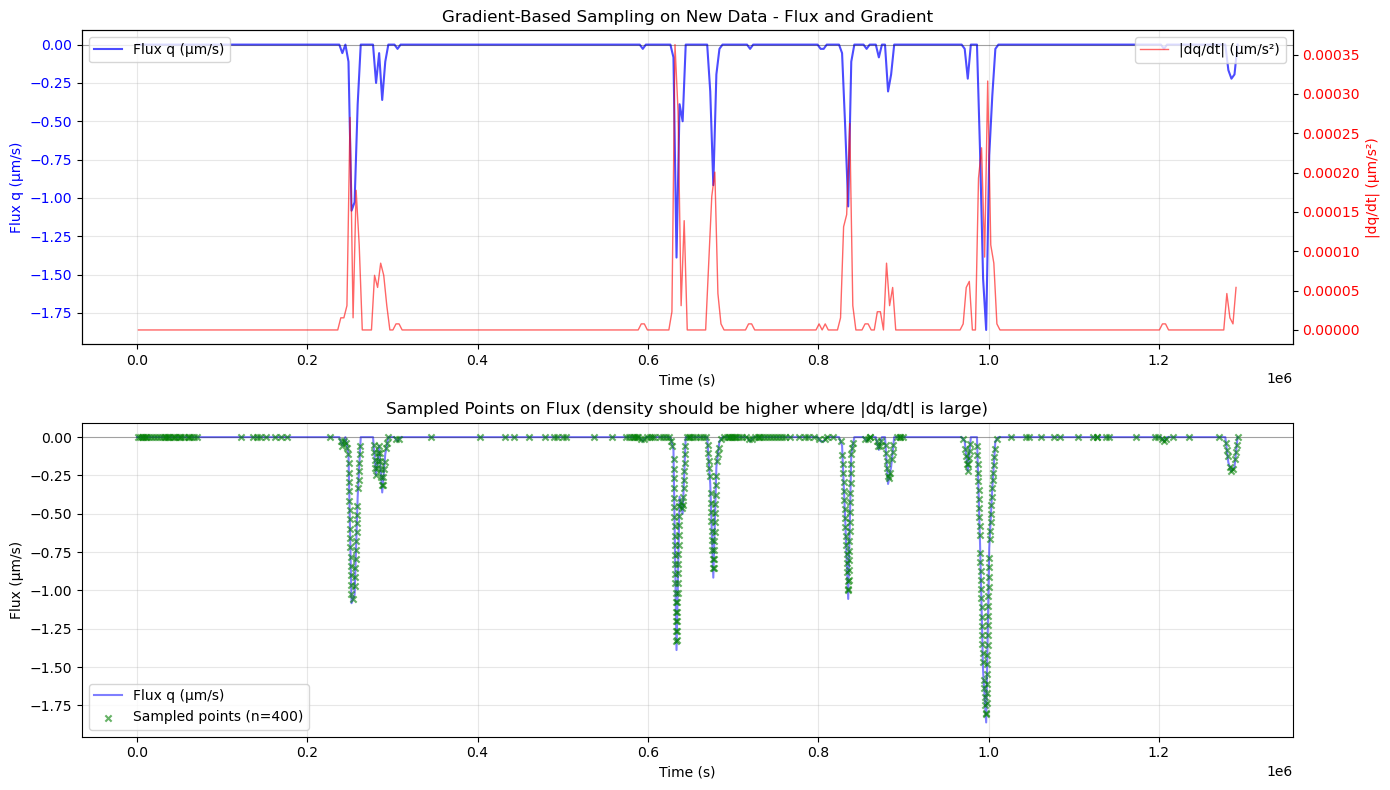

In [14]:
# Visualize gradient-based sampling on new data
from src.gradient_based_sampling import gradient_based_sampling, visualize_gradient_sampling

q0_times_t = torch.tensor(new_q0_data[0], dtype=torch.float32).to(device)
q0_values_t = torch.tensor(new_q0_data[1], dtype=torch.float32).to(device)

# Test gradient-based sampling on new data
t_bc_test, sample_info = gradient_based_sampling(
    q0_times_t,
    q0_values_t,
    batch_size_bc=400,
    device=device,
    use_interpolation=True,
    interp_ratio=0.80,
    neighbor_ratio=0.05,
    baseline_ratio=0.15,
    neighbor_expansion=2,
    gradient_threshold=0.7,
    power=2.0
)

print(f"\nGradient-Based Sampling Test:")
print(f"  Generated {len(t_bc_test)} samples")
print(f"  Interpolated: {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors: {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline: {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize
visualize_gradient_sampling(
    q0_times_t,
    q0_values_t,
    t_bc_test,
    sample_info,
    title='Gradient-Based Sampling on New Data'
)
plt.show()

In [15]:
from src.train_loop import finetune_pinn

print("="*70)
print("Starting Fine-Tuning with Gradient-Based Sampling")
print("="*70)

model, losses, comps, sample_losses, sample_comps, sample_epochs = finetune_pinn(
    checkpoint_path=BASE_CHECKPOINT,
    new_q0_data=new_q0_data,
    zb_initial=1.0,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,

    # Fine-tuning hyperparameters (lower lr, fewer epochs than base)
    n_epochs=10000,
    learning_rate=1e-4,

    # Training parameters (same as base)
    cache_size=10000,
    batch_size=500,
    resample_freq=500,
    boundary_ratio=0.7,
    high_residual_ratio=0.3,
    temperature=1.0,
    batch_size_bc=500,

    # Gradient-based boundary sampling parameters
    interp_ratio=0.80,
    neighbor_ratio=0.05,
    baseline_ratio=0.15,
    gradient_neighbor_expansion=2,
    gradient_threshold=0.7,
    gradient_power=2.0,

    # Fixed weights (no adaptive learning during fine-tuning)
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,

    # Device and GPU settings
    device=device,
    use_multi_gpu=True,
    use_amp=False,  # Set True for memory savings on GPU
    grad_accumulation_steps=1,

    # Checkpointing (isolated from base training)
    checkpoint_dir='checkpoints_finetune',
    checkpoint_freq=2000,  # Save every 2000 epochs
    keep_last_n_checkpoints=3,
)

print("\n" + "="*70)
print("Fine-Tuning Complete!")
print("="*70)

Starting Fine-Tuning with Gradient-Based Sampling
Loading pretrained model from: checkpoints_train/checkpoint_final.pt
Checkpoint loaded successfully
  Trained for 40000 epochs
  Normalization params: L=4.00, S_max=1.00e-07
  Network scaling: t_max_tilde=10.77, z_max_tilde=1.00

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.300
Time scale (T):             1.20e+05 s (33.33 hours)
Dimensionless α̃:            0.0200
Dimensionless S̃_max:        0.0400


Fine-Tuning Configuration
Base checkpoint: checkpoints_train/checkpoint_final.pt
Base training epochs: 40000

Preserved normalization parameters:
  soil_params: θs=0.4, θr=0.1, α=0.005, n=1.3
  L=4.00 m, S_max=1.00e-07 1/s
  Sy=0.3, zr=0.50 m

Preserved network scaling:
  t_max_tilde=10.7700 (from base model)
  z_max_tilde=1.0000

New boundary condition data:
  Time range: [0.0, 12

d:\Research\smap recharge\SMAP-Recharge-Flux\src\train_loop.py:469: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=10000)
Using weights from base model: {'pde': 10.0, 'surf': 50.0, 'wt_head': 1.0, 'wt_kin': 1.0, 'ic_h': 1.0, 'ic_zb': 1.0}
Checkpointing enabled: saving every 2000 epochs to checkpoints_finetune/

Starting fine-tuning for 10000 epochs | lr=1.00e-04
Device: cpu | GPUs available: 0
Fixed weights: True
Pool + Batch: cache_size=10000, batch_size=500, resample_freq=500
Boundary ratio: 70.0%, High residual ratio: 30.0%
Initial weights: {'pde': 10.0, 'surf': 50.0, 'wt_head': 1.0, 'wt_kin': 1.0, 'ic_h': 1.0, 'ic_zb': 1.0}


[   1/10000]
  Losses: total=1.043e-01
    PDE=1.485e-03, Surf=1.022e-01
    WT(h)=3.302e-04, WT(kin)=2.176e-04
    IC(h)=4.227e-05, IC(zb)=1.011e-05
  Weighted Gradients (L2 norm):
    PDE=0.000e+00, Surf=0.000e+00
    WT(h)=0.000e+00, WT(kin)=0.000e+00
    IC(h)=0.000e+00, IC(zb)=0.000e+00
    Total=0.000e+00
  Current weights:
    pde: 1.000e+01
    surf: 5.000e+01
    wt_head: 1.000e+00
    wt_kin

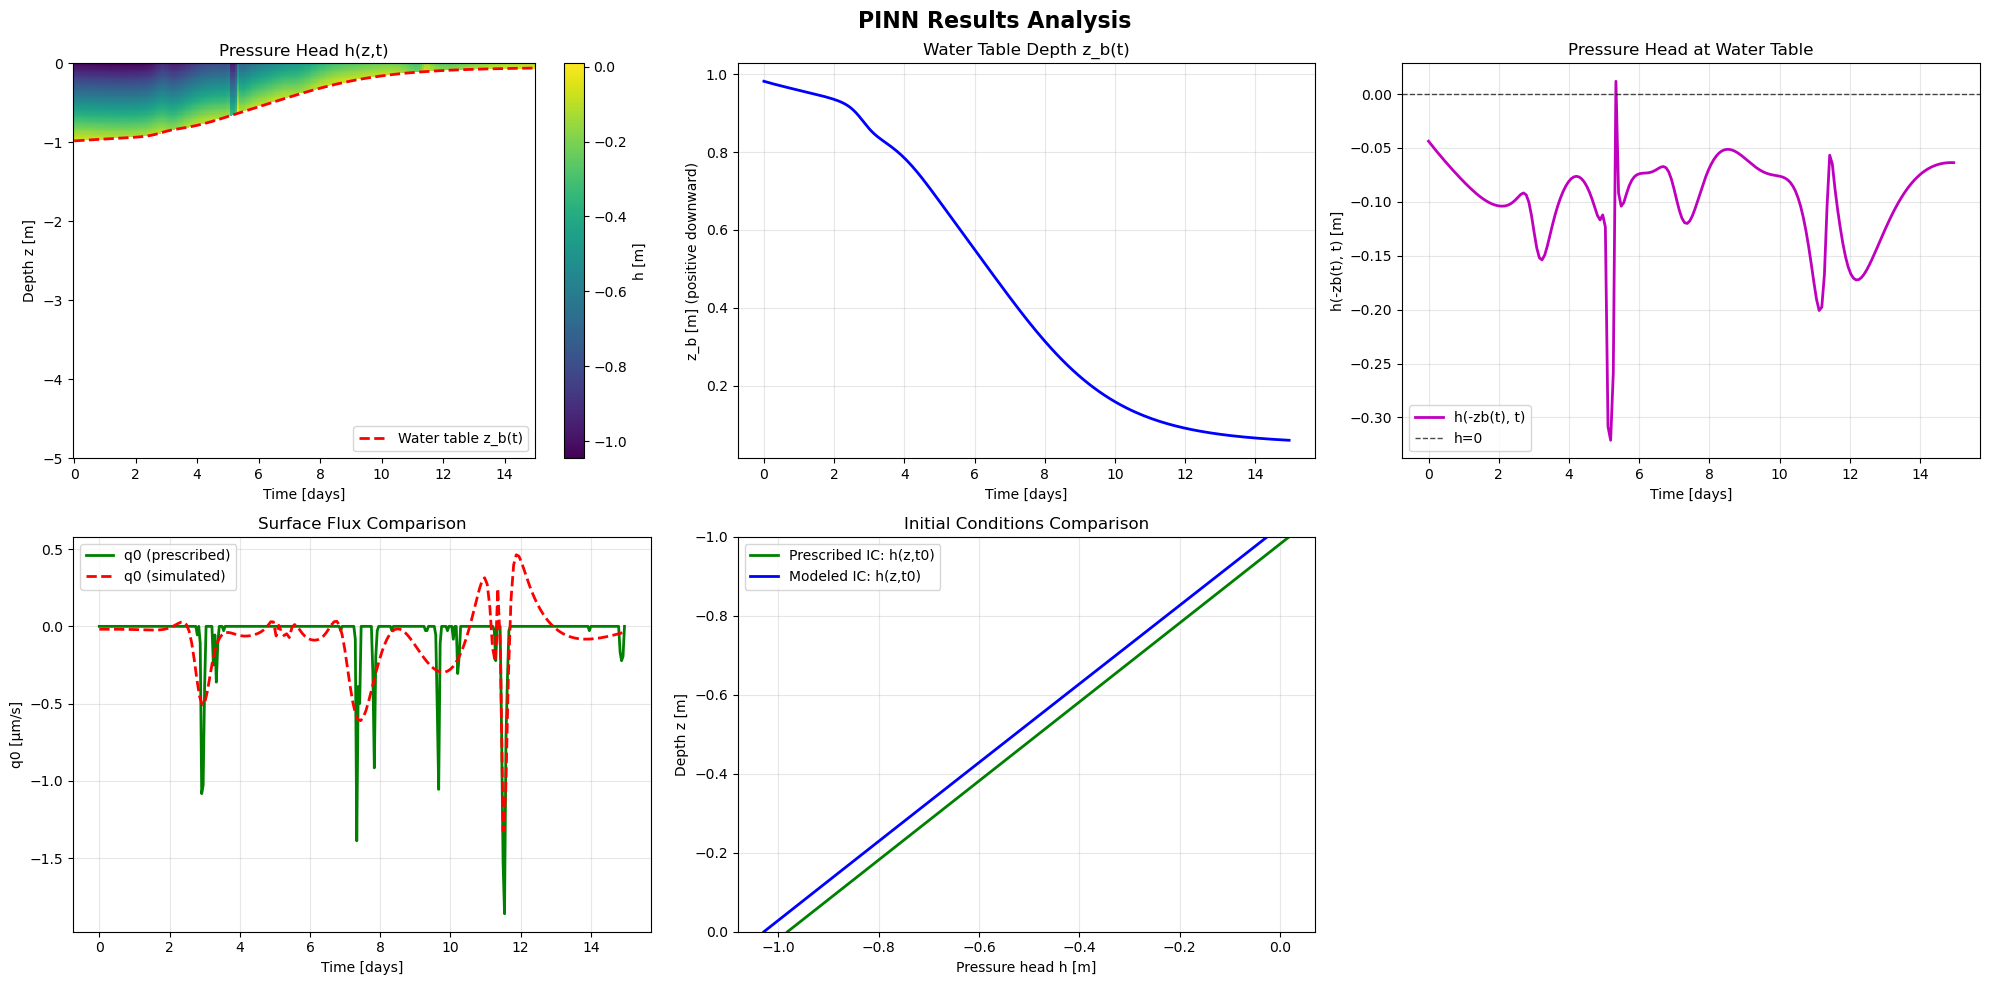


Summary Statistics:
Water table depth range: 0.060 to 0.982 m
Surface head range: -1.045 to -0.123 m
h(-zb(t), t) range: -0.321144 to 0.011819 m
Max |h(-zb(t), t)|: 0.321144 m (should be close to 0)
Max IC error: 0.047273 m


In [16]:
from src.visualization import plot_comprehensive_results
soil_params = {
    'theta_s': 0.4,
    'theta_r': 0.1,
    'alpha': 0.005,
    'n': 1.3,
    'Ks': 1e-5,
    'l': 0.5
}

# Plot comprehensive results
plot_comprehensive_results(model, new_q0_data, device=device, soil_params=soil_params)

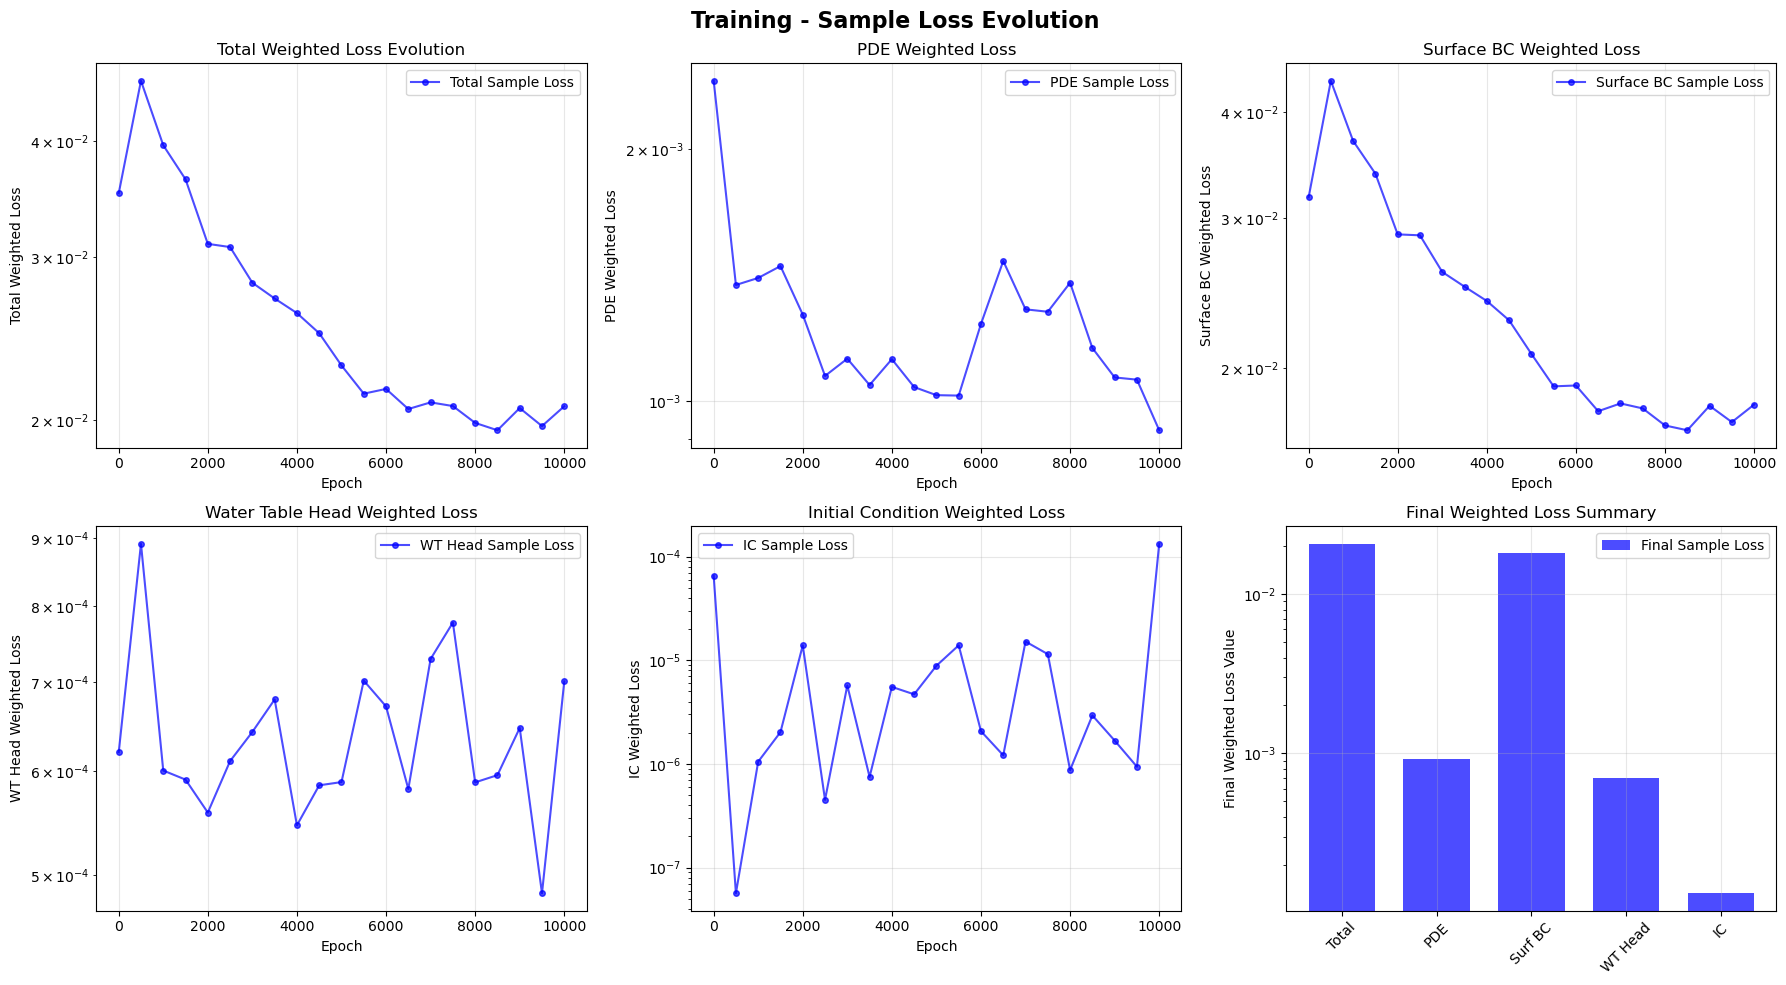

In [17]:
from src.visualization import plot_training_losses

# Plot training losses
plot_training_losses(losses, comps, sample_losses, sample_comps, sample_epochs)